# Current version : 9.D (2025-04-29)

In [ ]:
from module.misc import sample_name_import

name_dir = "circa-SD"

samples, samples_ids = sample_name_import(name_dir)

print(len(samples))
print(samples)

In [ ]:
import pandas as pd

In [ ]:
df_circa2 = pd.read_excel('data/cyc_analysis_nonzero_circa2.xlsx', sheet_name = 'sig_cyl_gene')
df_circa4 = pd.read_excel('data/cyc_analysis_nonzero_circa4.xlsx', sheet_name = 'sig_cyl_gene')

In [ ]:
circa4_gene = set(df_circa4['CycID'])
circa2_gene = set(df_circa2['CycID'])

In [ ]:
common_genes = circa4_gene.intersection(circa2_gene)

In [ ]:
len(common_genes), len(circa4_gene),len(circa2_gene)

In [ ]:
# library
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Use the venn2 function
venn2(subsets = (1449, 846, 560), set_labels = ('IGM', 'Salk'))
plt.show()


# Cycling genes

## Polar plot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample structure: replace this with your real data
# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': ['Arntl', 'Clock', 'Cry1', 'Cry2','Npas2', 'Nr1d1', 'Per2', 'Per3','Rorc',
                            'Arntl','Clock','Cry1','Nr1d1','Per1','Per2','Per3','Rorc'
                            ],
                    'Phase': [1.00, 8.38, 15.31, 12.89, 22.56, 8.96,15.30,13.06,16.54,
                              1.00, 3.15, 16.75, 9.02, 11.92, 16.23, 14.17, 17.06
                            ]
                    })

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

ax.set_yticks(range(1, len(gene_order) + 1))
ax.set_yticklabels(gene_order)
ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left", title='Gene')

plt.tight_layout()
plt.show()

## Cell type spe polar

In [132]:
import pandas as pd

dir_sum = '../R/Results/2025-06-25_circa4_celltype/Summary'

df = pd.read_excel(f'{dir_sum}/2025-06-25_circa4_cyc_siggene_by_celltype.xlsx', sheet_name=None, usecols=['CycID', 'meta2d_phase'])

In [133]:
clockgenelist=['Arntl', 'Clock', 'Cry1', 'Cry2', 'Npas2', 'Nr1d1', 'Per1', 'Per2', 'Per3', 'Rora', 'Rorb', 'Rorc']
dataset = pd.DataFrame()
for key in df.keys():
    subdf = df[key].filter(['CycID', 'meta2d_phase'], axis=1)
    subdf = subdf[subdf['CycID'].isin(clockgenelist)]
    dataset = pd.concat([dataset, subdf])

In [134]:
all_celltype_CG = dict(zip(dataset['CycID'], dataset['meta2d_phase']))

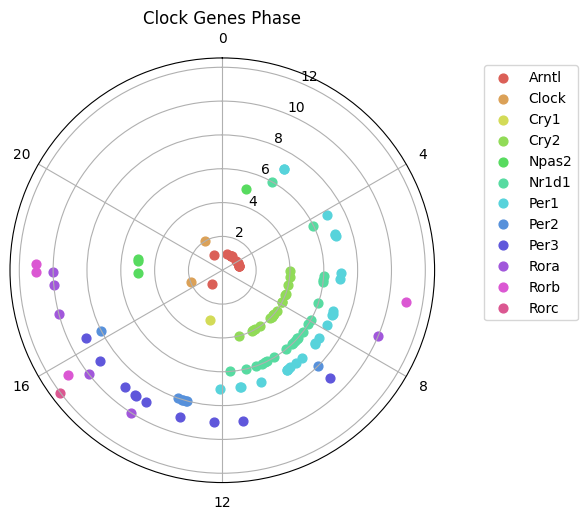

In [135]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample structure: replace this with your real data
# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': dataset['CycID'],
                    'Phase': dataset['meta2d_phase']
                    })
data = data.sort_values('Gene')

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

# # for gene in gene_order:
# gene = 'Per1'
# subset = data[data['Gene'] == gene]
# ax.hist(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene])  


# ax.set_yticks(range(1, len(gene_order) + 1))
# ax.set_yticklabels(gene_order)
# ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': dataset['CycID'],
                    'Phase': dataset['meta2d_phase']
                    })
data = data.sort_values('Gene')

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

# # for gene in gene_order:
# gene = 'Per1'
# subset = data[data['Gene'] == gene]
# ax.hist(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene])  


# ax.set_yticks(range(1, len(gene_order) + 1))
# ax.set_yticklabels(gene_order)
# ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

## Histo polar plot

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
run_namdate = "2025-06-25_circa4"
run_type = 'celltype'

dir_sum = f'../R/Results/{run_namdate}_{run_type}/Summary'

df_all = pd.read_excel(f'{dir_sum}/{run_namdate}_cyc_siggene_by_celltype.xlsx', sheet_name=None)
cycling_summary = pd.read_csv(f'{dir_sum}/{run_namdate}_cycling_gene_count_by_celltype.csv', index_col='cycling_gene_count')

In [ ]:
cycling_summary.iloc[1]

In [ ]:
for idx, celltype in enumerate(df_all.keys()):

    # Data preparation
    df = pd.DataFrame(data=zip(df_all[celltype]['CycID'], df_all[celltype]['meta2d_phase']))
    df.columns = ['Gene','Phase']
    df['Radians'] = df['Phase'] / 24 * 2 * np.pi

    # Plot
    plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)
    ax.set_theta_direction(-1)
    ax.set_theta_offset(np.pi / 2.0)
    ax.grid(True)

    ax.hist(df['Radians'], bins = 24)

    ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
    ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

    plt.title(f'Genes Phase in {celltype}')
    plt.savefig(f'Gallery/circa4/polar_gene_{celltype}.svg')
    plt.show()
    plt.close()


### Histo polar in region/gene panel

In [ ]:
import pandas as pd
from module.misc import genes_list

gene_list = genes_list('mitochondria')
region = 'SCH'
df_all = pd.read_excel(f'data/{region}_cyc_analysis.xlsx', sheet_name='sig_cyl_gene')

# Data preparation
df = pd.DataFrame(data=zip(df_all['CycID'], df_all['meta2d_phase']))
df.columns = ['Gene','Phase']
df = df[df['Gene'].isin(gene_list)]
df['Radians'] = df['Phase'] / 24 * 2 * np.pi

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

ax.hist(df['Radians'], bins = 24,
        #  color = 'green'
         )

ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
ax.set_xticklabels(['0', '2', '4','6', '8', '10','12','14', '16','18', '20','22'])

plt.title(f'Genes Phase in {region}')
# plt.savefig(f'Gallery/circa2/polar_gene_{region}.svg')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from module.misc import genes_list

region = 'SCH'
df_all = pd.read_excel(f'data/SCH_cyc_analysis.xlsx', sheet_name='sig_cyl_gene')
gene_list = genes_list('mitochondria')

# Data preparation
df = pd.DataFrame(data=zip(df_all['CycID'], df_all['meta2d_phase']))
df.columns = ['Gene','Phase']
df = df[df['Gene'].isin(gene_list)]
df['Radians'] = df['Phase'] / 24 * 2 * np.pi

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

ax.hist(df['Radians'], bins = 24,
        #  color = 'green'
         )

ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
ax.set_xticklabels(['0', '2', '4','6', '8', '10','12','14', '16','18', '20','22'])

plt.title(f'Genes Phase in {region}')
# plt.savefig(f'Gallery/circa2/polar_gene_{region}.svg')

## Phase comparison

In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [137]:
run_namdate_1 = "2025-06-26_circa4"
run_namdate_2 = "2025-06-26_SD1"
run_type = 'celltype'
cell_type_plot = 'Astro TE'

dir_sum_1 = f'../R/Results/{run_namdate_1}_{run_type}/Summary'
dir_sum_2 = f'../R/Results/{run_namdate_2}_{run_type}/Summary'

df_all_NS = pd.read_excel(f'{dir_sum_1}/{run_namdate_1}_cyc_siggene_analysis.xlsx', sheet_name=cell_type_plot)
df_all_SD = pd.read_excel(f'{dir_sum_2}/{run_namdate_2}_cyc_siggene_analysis.xlsx', sheet_name=cell_type_plot)

In [138]:
from module.misc import genes_list

gene_list_plot = genes_list("clock")

dataset_NS = pd.DataFrame()

subdf_all_NS = df_all_NS.filter(['CycID', 'meta2d_phase'], axis=1)
subdf_all_NS = subdf_all_NS[subdf_all_NS['CycID'].isin(gene_list_plot)]
dataset_NS = pd.concat([dataset_NS, subdf_all_NS])

dataset_SD = pd.DataFrame()
subdf_all_SD = df_all_SD.filter(['CycID', 'meta2d_phase'], axis=1)
subdf_all_SD = subdf_all_SD[subdf_all_SD['CycID'].isin(gene_list_plot)]
dataset_SD = pd.concat([dataset_SD, subdf_all_SD])

In [139]:
data = pd.DataFrame(index=gene_list_plot)

In [140]:
all_celltype_NS = dict(zip(dataset_NS['CycID'], dataset_NS['meta2d_phase']))
all_celltype_SD = dict(zip(dataset_SD['CycID'], dataset_SD['meta2d_phase']))

In [141]:
data['NS'] = data.index.map(all_celltype_NS)
data['SD'] = data.index.map(all_celltype_SD)
# data.dropna(inplace= True)
data['Gene'] = data.index
data['Diff'] = data['NS'] - data['SD']
data = data.sort_values(by='NS')

In [142]:

data['NS2'] = data['NS']
data['SD2'] = data['SD']

# for n in range(len(data)):
#     if data.iloc[n,data.columns.get_loc("Diff")] > 12:
#         if data.iloc[n,data.columns.get_loc("NS")] < data.iloc[n,data.columns.get_loc("SD")]:
#             data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("NS")] + 24
#         else:
#             data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("SD")] + 24
#     else:
#         data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("NS")]
#         data.iloc[n,data.columns.get_loc("SD")] = data.iloc[n,data.columns.get_loc("SD")]
thres = 12

for n in range(len(data)):
    if (abs(data.iloc[n,data.columns.get_loc("Diff")]) >= thres):
        if (data.iloc[n,data.columns.get_loc("SD")] > data.iloc[n,data.columns.get_loc("NS")]):
            data.iloc[n,data.columns.get_loc("SD2")] = data.iloc[n,data.columns.get_loc("SD")]-24
        elif (data.iloc[n,data.columns.get_loc("SD")] < data.iloc[n,data.columns.get_loc("NS")]):
            data.iloc[n,data.columns.get_loc("SD2")] = data.iloc[n,data.columns.get_loc("SD")] + 24
    else:
        data.iloc[n,data.columns.get_loc("SD2")] = data.iloc[n,data.columns.get_loc("SD")]
        data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("NS")]

# data = data.sort_values(by="Diff", ascending=False)
data = data.sort_index()

In [143]:
data

,NS,SD,Gene,Diff,NS2,SD2
Arntl,1.000053,NaN,Arntl,NaN,1.000053,NaN
Clock,NaN,NaN,Clock,NaN,NaN,NaN
Cry1,NaN,NaN,Cry1,NaN,NaN,NaN
Cry2,7.867642,4.905707,Cry2,2.961935,7.867642,4.905707
Npas2,18.502112,NaN,Npas2,NaN,18.502112,NaN
Nr1d1,9.087505,6.734954,Nr1d1,2.352552,9.087505,6.734954
Per1,8.328822,NaN,Per1,NaN,8.328822,NaN
Per2,NaN,NaN,Per2,NaN,NaN,NaN
Per3,11.481614,7.566277,Per3,3.915337,11.481614,7.566277
Rora,NaN,7.239505,Rora,NaN,NaN,7.239505


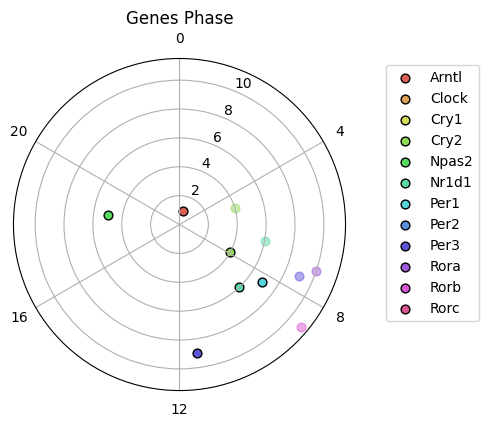

In [149]:
# Convert phase to radians for polar plot
data['Radians_NS'] = data['NS'] / 24 * 2 * np.pi
data['Radians_SD'] = data['SD'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data.index
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data.index.map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data.index.map(gene_colors)

# Plot
plt.figure(figsize=(5,5))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data.index == gene]
    ax.scatter(subset['Radians_NS'], subset['Radius'], label=gene, color=gene_colors[gene], s=40, edgecolors='black')
    ax.scatter(subset['Radians_SD'], subset['Radius'], color=gene_colors[gene], alpha = 0.5, s=40)

ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])
ax.set_ylabel(ylabel=None)
plt.title('Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

In [145]:
# Color palette
gene_order = data.index
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data.index.map(gene_colors)

In [146]:
# data = data[0:20]

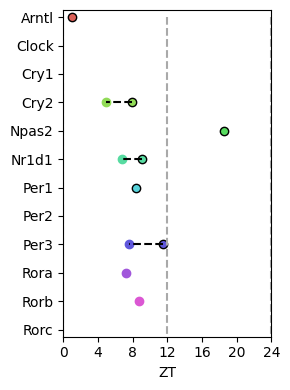

In [151]:
plt.figure(figsize=(3,4))
ax =ax = plt.subplot()

for n in range(len(data)):
    ax.hlines(y=n, xmin=data.iloc[n,data.columns.get_loc("NS2")], xmax=data.iloc[n,data.columns.get_loc("SD2")], linestyles='dashed', color = 'black')
    ax.scatter(x=data.iloc[n,data.columns.get_loc("NS2")],y=n,
               color = data.iloc[n,data.columns.get_loc("Color")],
                 edgecolors='black', label = data.index.values[n])
    ax.scatter(x=data.iloc[n,data.columns.get_loc("SD2")], y=n, color = data.iloc[n,data.columns.get_loc("Color")])
ax.set_xlim(0,24)
ax.set_ylim(-0.25, len(data)-0.75)
ax.set_xticks([0,4,8,12,16,20,24])
ax.set_xlabel('ZT')
ax.set_yticks(ticks = range(len(data)),labels = data['Gene'])
ax.vlines(x = [0,12,24], ymin=0, ymax=len(data), color = 'darkgrey', linestyles='dashed')
ax.invert_yaxis()
plt.tight_layout()

# plt.legend()

## Barplot

In [ ]:
df_gen_NS = pd.read_csv('../notebook/analysis/circa-SD/NS-genexpression-summary.csv', index_col="Celltype")
df_gen_SD = pd.read_csv('../notebook/analysis/circa-SD/SD-genexpression-summary.csv', index_col="Celltype")

In [ ]:
df_gen_NS.to_csv('../notebook/analysis/circa-SD/NS-genexpression-summary.csv')
df_gen_SD.to_csv('../notebook/analysis/circa-SD/SD-genexpression-summary.csv')

In [ ]:
run_namdate_1 = "2025-06-26_circa4"
run_namdate_2 = "2025-06-26_SD1"
run_type = 'celltype'

dir_sum_1 = f'../R/Results/{run_namdate_1}_{run_type}/Summary'
dir_sum_2 = f'../R/Results/{run_namdate_2}_{run_type}/Summary'

cycling_summary_1 = pd.read_csv(f'{dir_sum_1}/{run_namdate_1}_cycling_gene_per_group.csv', index_col='celltype')
cycling_summary_2 = pd.read_csv(f'{dir_sum_2}/{run_namdate_2}_cycling_gene_per_group.csv', index_col='celltype')

In [ ]:
NS_dict = dict(zip(cycling_summary_1.index,cycling_summary_1['cycling_gene_count']))
SD_dict = dict(zip(cycling_summary_2.index,cycling_summary_2['cycling_gene_count']))

df_gen_NS['Cycling_pval'] = df_gen_NS.index.map(NS_dict)
df_gen_SD['Cycling_pval'] = df_gen_SD.index.map(SD_dict)

In [ ]:
df_NS = pd.read_excel(f'{dir_sum_1}/{run_namdate_1}_cyc_siggene_analysis.xlsx', sheet_name=None, usecols=['CycID','meta2d_BH.Q'])
df_SD = pd.read_excel(f'{dir_sum_2}/{run_namdate_2}_cyc_siggene_analysis.xlsx', sheet_name=None, usecols=['CycID','meta2d_BH.Q'])


common = {}
sum_com = {}
common_cells = set(df_NS.keys()).intersection(set(df_SD.keys()))

for key in common_cells:
    # df_NS[key] = df_NS[key][df_NS[key]['meta2d_BH.Q']>=0.05]
    # df_SD[key] = df_SD[key][df_SD[key]['meta2d_BH.Q']>=0.05]
    common[key] = df_NS[key][df_NS[key]['CycID'].isin(df_SD[key]['CycID'])]
    sum_com[key] = len(common[key])

sum_com_df = pd.DataFrame({'Gene': sum_com.keys(),
                    'Common': sum_com.values()})
sum_com_df.index = sum_com_df['Gene']

In [ ]:
sum_com_dict = dict(zip(sum_com_df['Gene'],sum_com_df['Common']))
df_gen_NS['Common_pval'] = df_gen_NS.index.map(sum_com_dict)
df_gen_SD['Common_pval'] = df_gen_SD.index.map(sum_com_dict)


In [ ]:
df_NS_BH_nb = [len(df_NS[key]) for key in df_NS.keys()]
ddf_NS_BH_nb = pd.DataFrame(data ={'Expressed_genes':df_NS_BH_nb}, index = df_NS.keys())

df_SD_BH_nb = [len(df_SD[key]) for key in df_SD.keys()]
ddf_SD_BH_nb = pd.DataFrame(data ={'Expressed_genes':df_SD_BH_nb}, index = df_SD.keys())

NS_BH_dict = dict(zip(ddf_NS_BH_nb.index, ddf_NS_BH_nb['Expressed_genes']))
df_gen_NS['Cycling_BH'] = df_gen_NS.index.map(NS_BH_dict)

SD_BH_dict = dict(zip(ddf_SD_BH_nb.index, ddf_SD_BH_nb['Expressed_genes']))
df_gen_SD['Cycling_BH'] = df_gen_SD.index.map(SD_BH_dict)

In [ ]:
cycling_summary_1 = cycling_summary_1[cycling_summary_1.index.isin(cycling_summary_2.index)].sort_values(by='cycling_gene_count')
cycling_summary_2 = cycling_summary_2[cycling_summary_2.index.isin(cycling_summary_1.index)]

In [ ]:
df_gen_NS.sort_values(by='Common_pval',inplace=True)
df_gen_SD

In [ ]:
fig, ax = plt.subplots(figsize = (5,8))
ax.barh(y = df_gen_NS.index, width = -df_gen_NS['Expressed_genes'], label = 'Expressed', color = 'None', edgecolor ='blue')
ax.barh(y = df_gen_SD.index, width = df_gen_SD['Expressed_genes'], color = 'None', edgecolor = 'orange')
ax.barh(y = df_gen_NS.index, width = -df_gen_NS['Cycling_pval'], label = 'Cycling', color = 'blue', alpha = 0.5)
ax.barh(y = df_gen_SD.index, width= df_gen_SD['Cycling_pval'],  color = 'orange', alpha = 0.5 )
ax.barh(y = df_gen_NS.index, width=df_gen_NS['Common_pval'], label = 'Common', color = 'purple')
ax.barh(y = df_gen_SD.index, width=-df_gen_SD['Common_pval'], color = 'purple')
ax.vlines(x=0,ymin=-1,ymax=len(df_gen_NS), color = "black")
ax.set_ylim(-0.5,len(df_gen_NS))
ax.legend(loc='lower left')
ax.set_title('Cycling genes in normal and disrupted sleep (pval)')

In [ ]:
len(df_gen_SD.index)

# Test Squidpy

In [ ]:
import squidpy as sq
import pandas as pd
import scanpy as sc
import numpy as np

In [ ]:
adata = sc.read_h5ad('../notebook/h5ad/circa-SD/circa-SD_final.h5ad.gz')
dir_notebook = '/media/volume/volume_spatial/hugo/notebook'


In [ ]:
# df = pd.DataFrame(data=adata.X.toarray(), index=adata.obs_names, columns=adata.var_names)

# from module.xenium_preprocessing import add_annotations
# df = add_annotations(adata,df)
name_dir = 'circa-SD'
df.to_parquet(f"{dir_notebook}/csv/{name_dir}/{name_dir}_norm_combined.parquet")

In [ ]:
df.sample(3)

In [ ]:
adata = adata[adata.obs['sample'] == '3161-3']
# adata = adata[adata.obs['region_automap_name']=='CTX']
adata.obsm['spatial'] = adata.obsm['coord_xy']

In [ ]:
adata

In [ ]:
sq.gr.spatial_neighbors(adata)

In [ ]:
sq.gr.nhood_enrichment(adata, cluster_key="cell type")

In [ ]:
sq.pl.nhood_enrichment(adata, cluster_key="cell type")

# Moran

In [ ]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata,
    mode="moran",
    n_perms=100,
    n_jobs=5,
)
adata.uns["moranI"].head(15)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Gfap",
        "Trem2",
        "Bhlhe22"
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Folr1",
        "Slc17a7",
        "Rsph1"
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Gpr88",
        "Ppp1r1b",
        "Foxj1"
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Sostdc1",
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
grp = adata.obs['run'].unique()
grp

In [ ]:
df2 = adata[adata.obs['run'] == 'circa4'].obs.groupby('sample')['region_automap_name'].value_counts()

In [ ]:
df2.to_csv('temp_region_circa4.csv')

# Test run R

In [ ]:
%load_ext rpy2.ipython

In [ ]:
%%R
a = 1
print(a)

# DEG

## Data import

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
cell_nb = pd.read_csv('../notebook/analysis/circa-SD/summary_cell_number.csv')
cell_nb

In [ ]:
df_all = pd.read_excel('../notebook/analysis/circa-SD/DEG_celltype_no-filter.xlsx', sheet_name=None)
for key in df_all.keys():
    if "SD1" in df_all[key]["group"].unique():
        df_all[key] = df_all[key][df_all[key]['group'] == 'SD1']
    df_all[key].index = df_all[key]['names']

In [ ]:
df_all['HY Glut']{}

In [ ]:
df_filter = pd.read_excel('../notebook/analysis/circa-SD/DEG_celltype_filter.xlsx', sheet_name=None)

for key in df_filter.keys():
    df_filter[key] = df_filter[key][df_filter[key]['group'] == 'SD1']
    df_filter[key].index = df_filter[key]['names']

In [ ]:
### Alternative fitlering
df_filter = {}
for key in df_all.keys():
    df_filter[key] = df_all[key][(df_all[key]['pvals_adj'] < 0.05) & (df_all[key]['pct_nz_group'] > 0.1) & (abs(df_all[key]['logfoldchanges']) > 0.26) ]
df_filter['SCH Gaba']

## Quantif

In [ ]:
deg_quant = [len(df_filter[key]) for key in df_filter.keys()]
deg_up = [len(df_filter[key][df_filter[key]['logfoldchanges'] > 0]) for key in df_filter.keys()]
deg_down = [len(df_filter[key][df_filter[key]['logfoldchanges'] < 0]) for key in df_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Celltype' : df_filter.keys(),
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Celltype']
df_deg_quant

In [ ]:
plt.figure(figsize=(8,8))
df_deg_quant.sort_values(by='nb_DEG', inplace=True)
plt.barh(y = df_deg_quant['Celltype'], width=df_deg_quant['Upregulated'])
plt.barh(y = df_deg_quant['Celltype'], width=-df_deg_quant['Downregulated'])
plt.vlines(x=0, ymin=-1,ymax=len(df_deg_quant), color = 'black', linestyles='dashed')

## Volcano plot

In [ ]:
key = 'SCH Gaba'

plt.figure(figsize=(10,10))
plt.vlines(x=(-0.26,0.26), ymin=df_filter[key]['pvals_adj'].min(), ymax=1, color = "black", linestyles='dashed')
plt.hlines(y=0.05, xmin=-1, xmax=1, color = "black", linestyles='dashed')

plt.scatter(x=df_all[key]['logfoldchanges'], y = df_all[key]['pvals_adj'], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= df_filter[key]['logfoldchanges'], y=df_filter[key]['pvals_adj'], s=5, alpha=1, color = 'red')
# for idx, gene in enumerate(df_filter[key]['names']):
#     plt.text(df_filter[key]['logfoldchanges'][idx], df_filter[key]['pvals_adj'][idx], str(gene), color = 'black', fontsize = 8, ha= 'center')
plt.yscale('log')
plt.xlim(-4,4)
# plt.ylim(0,50)
plt.gca().invert_yaxis()
plt.xlabel('Log2 Foldchange')
plt.ylabel('Adjusted p-value')
plt.savefig('Gallery/volcano_plot_SCN.svg')

In [ ]:
df_filter[key].index = df_filter[key]['names']

## DEG per regions

In [ ]:
import os

directory_DEG = '../notebook/analysis/circa-SD/DEG_region/'
all_regions = os.listdir(directory_DEG)

In [ ]:
astro_DEG = {}
for file in all_regions:
    region = file.split("_")[0]
    print(region)
    df = pd.read_excel(f'{directory_DEG}{file}', sheet_name= None)
    astro_DEG[region] = df['Astro TE']

In [124]:
astro_DEG

{'SCH':          names     scores  logfoldchanges         pvals     pvals_adj  \
 0       Eif4g1  12.745697        0.696432  3.294347e-37  1.649150e-33   
 1      Atp6ap2  12.414353        0.668385  2.184434e-35  5.467638e-32   
 2          Pkm  12.256068        0.596704  1.558808e-34  2.601130e-31   
 3        Hsph1  11.892290        0.625913  1.297977e-32  1.367117e-29   
 4         Ldha  11.888056        0.666697  1.365479e-32  1.367117e-29   
 ...        ...        ...             ...           ...           ...   
 10007     Ldha -11.888056       -0.666697  1.365479e-32  1.367117e-29   
 10008    Hsph1 -11.892290       -0.625913  1.297977e-32  1.367117e-29   
 10009      Pkm -12.256068       -0.596704  1.558808e-34  2.601130e-31   
 10010  Atp6ap2 -12.414353       -0.668385  2.184434e-35  5.467638e-32   
 10011   Eif4g1 -12.745697       -0.696432  3.294347e-37  1.649150e-33   
 
        pct_nz_group  pct_nz_reference   group  
 0          0.491160          0.292510  circa4  
 1   

In [155]:
for key in astro_DEG.keys():
    astro_DEG[key] = astro_DEG[key][astro_DEG[key]['group'] == 'SD1']
    astro_DEG[key].index = astro_DEG[key]['names']

astro_DEG_filter = {}

for key in astro_DEG.keys():
    astro_DEG_filter[key] = astro_DEG[key][(astro_DEG[key]['pvals_adj'] < 0.05)
                                           & (astro_DEG[key]['pct_nz_group'] > 0.15)
                                           & (abs(astro_DEG[key]['logfoldchanges']) > 0.26)
                                           ]

In [156]:
deg_quant = [len(astro_DEG_filter[key]) for key in astro_DEG_filter.keys()]
deg_up = [len(astro_DEG_filter[key][astro_DEG_filter[key]['logfoldchanges'] > 0]) for key in astro_DEG_filter.keys()]
deg_down = [len(astro_DEG_filter[key][astro_DEG_filter[key]['logfoldchanges'] < 0]) for key in astro_DEG_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Region' : astro_DEG_filter.keys(),
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Region']
df_deg_quant

,Region,nb_DEG,Upregulated,Downregulated
Region,,,,
SCH,SCH,337,6,331
CTX,CTX,121,20,101
VLMC,VLMC,173,43,130
HIPP,HIPP,237,38,199
STR,STR,160,34,126
HY,HY,184,53,131
WM,WM,169,62,107


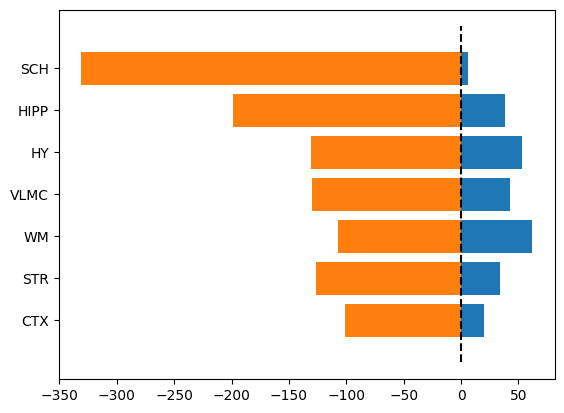

In [157]:
plt.figure()
df_deg_quant.sort_values(by='nb_DEG', inplace=True)
plt.barh(y = df_deg_quant['Region'], width=df_deg_quant['Upregulated'])
plt.barh(y = df_deg_quant['Region'], width=-df_deg_quant['Downregulated'])
plt.vlines(x=0, ymin=-1,ymax=len(df_deg_quant), color = 'black', linestyles='dashed')

In [158]:
astro_DEG_filter['SCH'].sort_values(by="logfoldchanges")

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,group
names,,,,,,,,
Tubb2b,Tubb2b,-11.208528,-0.756174,3.703036e-29,1.544783e-26,0.174299,0.319534,SD1
Tsc22d3,Tsc22d3,-11.226606,-0.738296,3.018496e-29,1.373690e-26,0.282215,0.440707,SD1
Eif4g1,Eif4g1,-12.745697,-0.696432,3.294347e-37,1.649150e-33,0.292510,0.491160,SD1
Tubb3,Tubb3,-11.484219,-0.683611,1.583604e-30,1.321253e-27,0.300319,0.470893,SD1
Slc24a3,Slc24a3,-9.717752,-0.679258,2.533131e-22,2.641844e-20,0.193468,0.318241,SD1
...,...,...,...,...,...,...,...,...
Fabp7,Fabp7,2.422830,0.466706,1.540014e-02,3.216052e-02,0.268371,0.256576,SD1
Marcks,Marcks,5.845387,0.591517,5.053936e-09,4.022258e-08,0.438055,0.416559,SD1
Cadps2,Cadps2,3.959766,0.664572,7.502310e-05,2.504524e-04,0.267306,0.242777,SD1


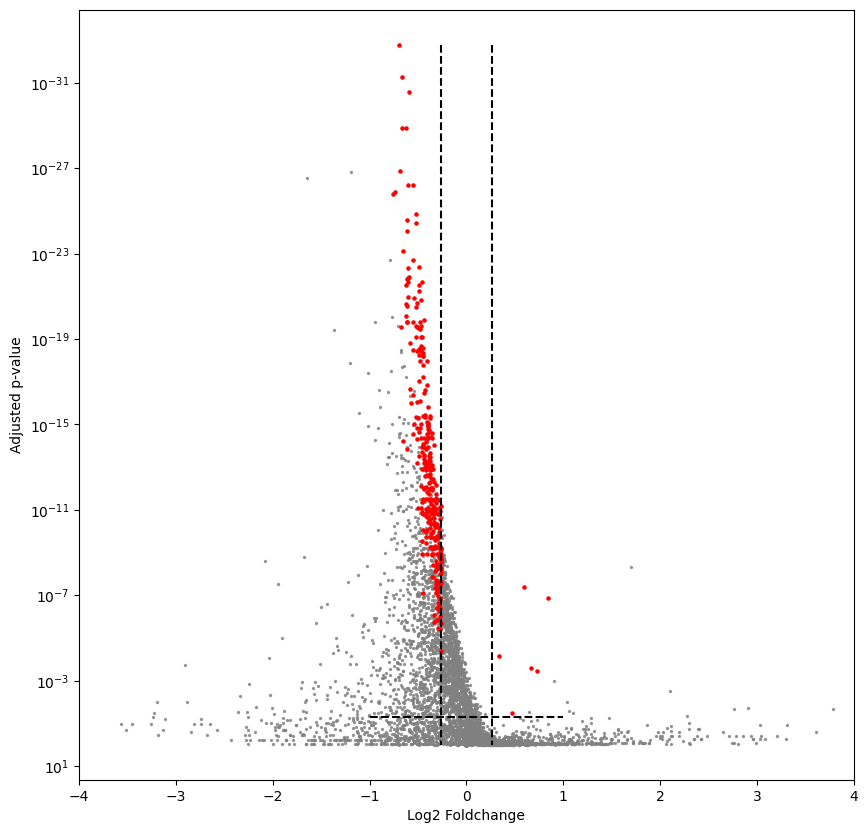

In [161]:
key = 'SCH'

plt.figure(figsize=(10,10))
plt.vlines(x=(-0.26,0.26), ymin=astro_DEG_filter[key]['pvals_adj'].min(), ymax=1, color = "black", linestyles='dashed')
plt.hlines(y=0.05, xmin=-1, xmax=1, color = "black", linestyles='dashed')

plt.scatter(x=astro_DEG[key]['logfoldchanges'], y = astro_DEG[key]['pvals_adj'], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= astro_DEG_filter[key]['logfoldchanges'], y=astro_DEG_filter[key]['pvals_adj'], s=5, alpha=1, color = 'red')
# for idx, gene in enumerate(df_filter[key]['names']):
#     plt.text(df_filter[key]['logfoldchanges'][idx], df_filter[key]['pvals_adj'][idx], str(gene), color = 'black', fontsize = 8, ha= 'center')
plt.yscale('log')
plt.xlim(-4,4)
# plt.ylim(0,50)
plt.gca().invert_yaxis()
plt.xlabel('Log2 Foldchange')
plt.ylabel('Adjusted p-value')
plt.savefig('Gallery/volcano_plot_SCN.svg')